# Notebook 1: Dane i przetwarzanie wstępne

**Autor:** Michał Bogdański

**Opis:** Projekt realizuje sentymentu recenzji steam po angielsku. Porównujemy podejście klasyczne (TF-IDF + SVM) z podejściem opartym na Transformerach (HerBERT).

**Źródło danych:** Zbiór `Steam Reviews` z kaggle.com – podział na oceny pozytywne i negatywne.

W tym notebooku:
1. Ładujemy dane i wybieramy tylko recenzje gry Final Fantasy XIII
2. Przeprowadzamy eksploracyjną analizę danych (EDA)
3. Wykonujemy przetwarzanie wstępne tekstu
4. Dzielimy dane na zbiory treningowy, walidacyjny i testowy

## 1. Instalacja i import bibliotek

In [3]:
!pip install -r requirements.txt -q
!python -m spacy download en_core_web_sm -q

✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import spacy
import unicodedata
from sklearn.model_selection import train_test_split

# Ustawienia wyświetlania
plt.rcParams["figure.figsize"] = (10, 6)
sns.set_style("whitegrid")
pd.set_option("display.max_colwidth", 200)

## 2. Załadowanie danych

Korzystamy ze zbioru `Steam Reviews` dostępnego na kaggle.com. Zbiór zawiera recenzje gier ze steam (pozytywne/negatywne)

In [12]:
df = pd.read_csv("steam_reviews.csv")

# Usunięcie pustych wierszy
df = df.dropna(subset=['review_text', 'review_score'])

print(f"Liczba rekordów: {len(df)}")
print(f"Kolumny: {list(df.columns)}")
df.head()

Liczba rekordów: 6409801
Kolumny: ['app_id', 'app_name', 'review_text', 'review_score', 'review_votes']


,app_id,app_name,review_text,review_score,review_votes
0,10,Counter-Strike,Ruined my life.,1,0
1,10,Counter-Strike,"This will be more of a ''my experience with this game'' type of review, because saying things like ''great gameplay'' will not suit something I've experienced with Counter-Strike. Here you go: I ...",1,1
2,10,Counter-Strike,This game saved my virginity.,1,0
3,10,Counter-Strike,• Do you like original games? • Do you like games that don't lag? • Do you like games you can run on low end PC's? • Do you like games where you don't meet children who have slept with your mother...,1,0
4,10,Counter-Strike,"Easy to learn, hard to master.",1,1


In [13]:
print("Podgląd kolumn i typów:")
print(df.dtypes)

Podgląd kolumn i typów:
app_id          int64
app_name          str
review_text       str
review_score    int64
review_votes    int64
dtype: object


### 2.1. Dostosowanie zbioru danych

Wybieramy tylko recenzje gry Final Fantasy XIII oraz kolumny review_text i review_score, ponieważ tylko one są nam potrzebne

In [15]:
df = df[df['app_name'] == 'FINAL FANTASY XIII'][['review_text', 'review_score']]

# Ewentualny zapis nowego zbioru do pliku csv
df.to_csv('final_fantasy_XIII.csv', index=False)

# review_score, 1 - pozytywne, -1 - negatywne
TEXT_COL = "review_text"
RATING_COL = "review_score"

print("Rozkład klas w zbiorze:")
print(df[RATING_COL].value_counts())

Rozkład klas w zbiorze:
review_score
 1    2805
-1    1094
Name: count, dtype: int64


## 3. Eksploracyjna analiza danych (EDA)

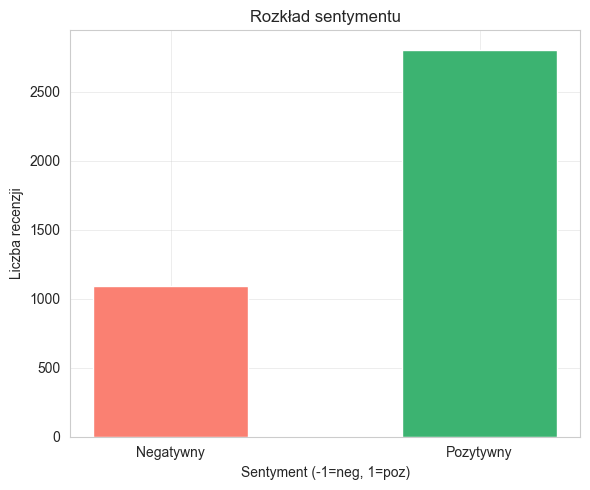

In [16]:
# Rozkład recenzji
counts = df[RATING_COL].value_counts().sort_index()
labels = ["Negatywny", "Pozytywny"]
colors = ["salmon", "mediumseagreen"]

plt.figure(figsize=(6, 5))
plt.bar(labels, counts, color=colors, width=0.5)

plt.title("Rozkład sentymentu")
plt.xlabel("Sentyment (-1=neg, 1=poz)")
plt.ylabel("Liczba recenzji")

plt.tight_layout()
plt.show()

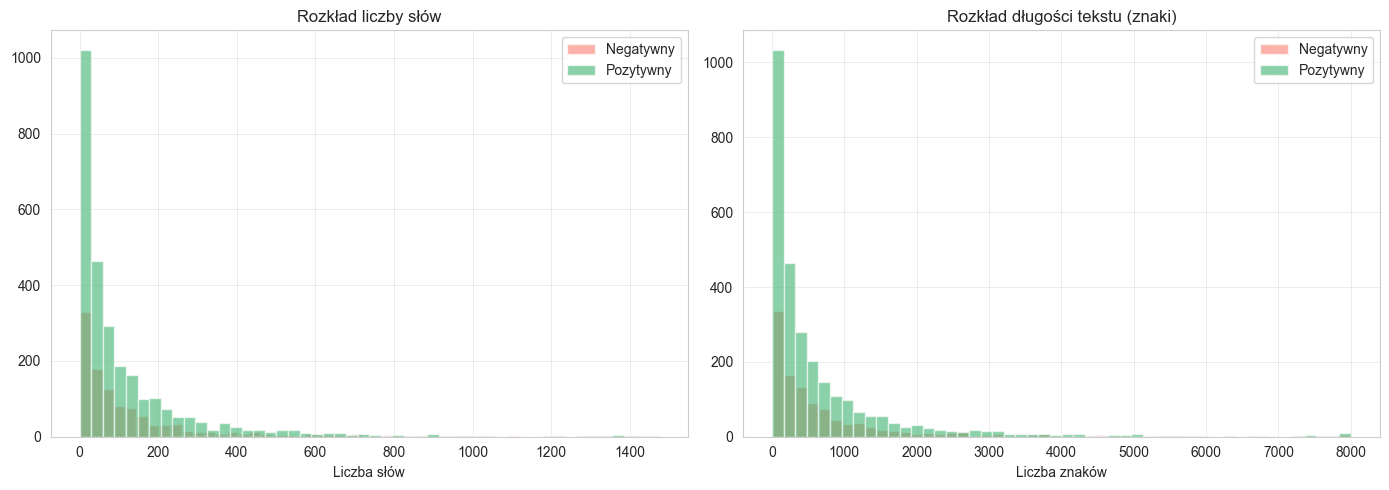

Statystyki długości recenzji (słowa):
               count        mean         std  min   25%   50%    75%     max
review_score                                                                
-1            1094.0  138.809872  200.824003  1.0  25.0  67.5  162.0  1435.0
 1            2805.0  121.104100  185.987776  0.0  17.0  53.0  144.0  1473.0


In [17]:
# Długość recenzji
df["text_length"] = df[TEXT_COL].astype(str).apply(len)
df["word_count"] = df[TEXT_COL].astype(str).apply(
    lambda x: len(x.split())
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for sent, color, label in [(-1, "salmon", "Negatywny"), (1, "mediumseagreen", "Pozytywny")]:
    subset = df[df[RATING_COL] == sent]
    axes[0].hist(subset["word_count"], bins=50, alpha=0.6, label=label, color=color)
    axes[1].hist(subset["text_length"], bins=50, alpha=0.6, label=label, color=color)

axes[0].set_title("Rozkład liczby słów")
axes[0].set_xlabel("Liczba słów")
axes[0].legend()

axes[1].set_title("Rozkład długości tekstu (znaki)")
axes[1].set_xlabel("Liczba znaków")
axes[1].legend()

plt.tight_layout()
plt.show()

print("Statystyki długości recenzji (słowa):")
print(df.groupby(RATING_COL)["word_count"].describe())

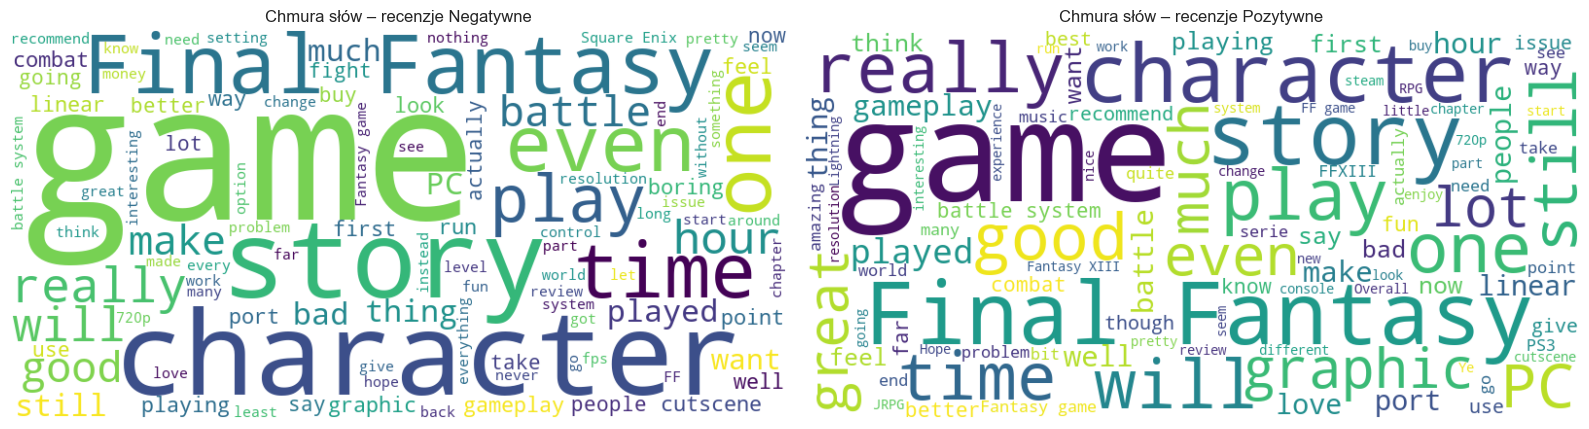

In [18]:
# Najczęstsze słowa dla każdego sentymentu
from wordcloud import WordCloud

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, (sent, title) in enumerate([(-1, "Negatywne"), (1, "Pozytywne")]):
    texts = " ".join(df[df[RATING_COL] == sent][TEXT_COL].astype(str))
    wc = WordCloud(
        width=800, height=400, background_color="white", max_words=100
    ).generate(texts)
    axes[idx].imshow(wc, interpolation="bilinear")
    axes[idx].set_title(f"Chmura słów – recenzje {title}")
    axes[idx].axis("off")

plt.tight_layout()
plt.show()

## 4. Przetwarzanie wstępne tekstu

In [19]:
# Ładowanie modelu spaCy dla języka angielskiego
nlp = spacy.load("en_core_web_sm", disable=["ner", "parser"])

def preprocess_text(text):
    """Nowoczesny pipeline: normalizacja → spaCy (tokenizacja + POS + lematyzacja) → filtrowanie."""

    # 1. Minimalna normalizacja (spaCy radzi sobie z resztą)
    text = unicodedata.normalize('NFC', text)
    text = re.sub(r'https?://\S+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()

    # 2. Przetwarzanie przez spaCy (tokenizacja + POS + lematyzacja w jednym kroku)
    doc = nlp(text)

    # 3. Filtrowanie: bez stop words, bez interpunkcji, bez spacji
    tokens = []
    for token in doc:
        if token.is_stop or token.is_punct or token.is_space:
            continue
        tokens.append(token.lemma_.lower())

    return " ".join(tokens)


# Przykład działania
sample_text = df[TEXT_COL].iloc[0]
print(f"Oryginał: {sample_text[:200]}")
print(f"\nPo przetworzeniu: {preprocess_text(sample_text)[:200]}")

Oryginał: This game has a tremendous polarizing effect on gamers. Either you love it, or you hate it. Hence I'm not surprised to see such mixed reviews. (Of course, the poor port is adding fuel to the negative 

Po przetworzeniu: game tremendous polarizing effect gamer love hate surprised mixed review course poor port add fuel negative flame address view later come play final fantasy game entry point franchise play jrpg pc ps3


In [20]:
# Przetwarzanie wstępne dla podejścia klasycznego
# (Transformer będzie korzystał z surowego tekstu)
print("Przetwarzanie tekstu... (może potrwać kilka minut)")
df["text_clean"] = df[TEXT_COL].astype(str).apply(preprocess_text)

# Usunięcie pustych rekordów po przetworzeniu
df = df[df["text_clean"].str.len() > 0].reset_index(drop=True)
print(f"Rekordów po przetworzeniu: {len(df)}")

Przetwarzanie tekstu... (może potrwać kilka minut)
Rekordów po przetworzeniu: 3893


In [21]:
# Ograniczenie do rozsądnej liczby przykładów (Google Colab ma limity pamięci)
MAX_SAMPLES = 5000

if len(df) > MAX_SAMPLES:
    df_sample = df.sample(n=MAX_SAMPLES, random_state=42).reset_index(drop=True)
    print(f"Losowo wybrano {MAX_SAMPLES} próbek z {len(df)}")
else:
    df_sample = df.copy()
    print(f"Używamy pełnego zbioru: {len(df_sample)} próbek")

# Podział: 70% trening, 15% walidacja, 15% test
train_df, temp_df = train_test_split(
    df_sample, test_size=0.3, random_state=42, stratify=df_sample[RATING_COL]
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, random_state=42, stratify=temp_df[RATING_COL]
)

print(f"\nRozmiary zbiorów:")
print(f"  Treningowy: {len(train_df)}")
print(f"  Walidacyjny: {len(val_df)}")
print(f"  Testowy: {len(test_df)}")

print(f"\nRozkład sentymentu w zbiorze treningowym:")
print(train_df[RATING_COL].value_counts(normalize=True))

Używamy pełnego zbioru: 3893 próbek

Rozmiary zbiorów:
  Treningowy: 2725
  Walidacyjny: 584
  Testowy: 584

Rozkład sentymentu w zbiorze treningowym:
review_score
 1    0.718899
-1    0.281101
Name: proportion, dtype: float64


In [22]:
# Zapis przetworzonych danych do plików CSV
train_df.to_csv("train.csv", index=False)
val_df.to_csv("val.csv", index=False)
test_df.to_csv("test.csv", index=False)

print("Dane zapisane do plików: train.csv, val.csv, test.csv")
print("\nKolumny w pliku:")
print(f"  '{TEXT_COL}' - oryginalny tekst (dla Transformerów)")
print(f"  'text_clean' - przetworzony tekst (dla podejścia klasycznego)")
print(f"  '{RATING_COL}' - etykieta (-1=negatywny, 1=pozytywny)")

Dane zapisane do plików: train.csv, val.csv, test.csv

Kolumny w pliku:
  'review_text' - oryginalny tekst (dla Transformerów)
  'text_clean' - przetworzony tekst (dla podejścia klasycznego)
  'review_score' - etykieta (-1=negatywny, 1=pozytywny)


## Podsumowanie

W tym notebooku:
- Pobraliśmy i dostosowaliśmy zbiór recenzji gier w języku angielskim
- Przeprowadziliśmy EDA: rozkłady ocen, długości recenzji, chmury słów
- Wykonaliśmy przetwarzanie wstępne: czyszczenie, lematyzacja, usunięcie stopwords
- Podzieliliśmy dane na zbiory: train (70%), val (15%), test (15%)

Dane są gotowe do użycia w kolejnych notebookach.